# Renewable Energy Shortfall Analysis for Germany (2012–2020)

This notebook combines:

- **Germany electricity data** from Open Power System Data (OPSD)
- **Weather data** from NASA POWER for five German cities

The goal is to create a unified dataset for analyzing and forecasting renewable energy shortfalls.

## Variables Used

### Energy Variables
- **load_mw**: Germany electricity load in MW
- **wind_generation_mw**: Germany wind generation in MW
- **solar_generation_mw**: Germany solar generation in MW
- **shortfall_mw**: Difference between load and renewable generation

### Weather Variables
- **irradiance_wm2**: Average solar irradiance across selected German cities
- **wind_speed_10m_ms**: Average wind speed at 10 m
- **temperature_2m_c**: Average air temperature at 2 m

## Study Period
2012 to 2020

## Selected Locations for Weather Averaging
- Berlin
- Hamburg
- Munich
- Frankfurt
- Cologne

In [1]:
# Imports
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#faf6fb",
    "axes.edgecolor": "#7a4d7e",
    "axes.labelcolor": "#5c2f63",
    "axes.titlecolor": "#5c2f63",
    "xtick.color": "#5c2f63",
    "ytick.color": "#5c2f63",
    "grid.color": "#d9b3df",
    "grid.alpha": 0.4,
    "text.color": "#5c2f63",
    "axes.grid": True,
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "legend.frameon": False,
    "lines.linewidth": 2,
    "patch.edgecolor": "white"
})
from cycler import cycler

mpl.rcParams["axes.prop_cycle"] = cycler(color=[
    "#c06bb7",  # pink-purple
    "#9b59b6",  # purple
    "#d16ba5",  # rosy pink
    "#7b68ee",  # soft violet
    "#e08adf"   # light orchid
])

### Download Germany Energy Data from OPSD

This section loads hourly electricity load, wind generation, and solar generation data for Germany from the Open Power System Data platform.

In [3]:
opsd_url = "https://data.open-power-system-data.org/time_series/latest/time_series_60min_singleindex.csv"

opsd = pd.read_csv(
    opsd_url,
    usecols=[
        "utc_timestamp",
        "DE_load_actual_entsoe_transparency",
        "DE_wind_generation_actual",
        "DE_solar_generation_actual",
    ]
)

opsd["utc_timestamp"] = pd.to_datetime(opsd["utc_timestamp"], utc=True)

opsd = opsd[
    (opsd["utc_timestamp"] >= "2012-01-01") &
    (opsd["utc_timestamp"] < "2021-01-01")
].copy()

opsd = opsd.rename(columns={
    "DE_load_actual_entsoe_transparency": "load_mw",
    "DE_wind_generation_actual": "wind_generation_mw",
    "DE_solar_generation_actual": "solar_generation_mw"
})

opsd = opsd.dropna(subset=["load_mw", "wind_generation_mw", "solar_generation_mw"])

opsd["shortfall_mw"] = (
    opsd["load_mw"]
    - opsd["wind_generation_mw"]
    - opsd["solar_generation_mw"]
)

print("OPSD shape:", opsd.shape)
opsd.head()

OPSD shape: (50295, 5)


,utc_timestamp,load_mw,solar_generation_mw,wind_generation_mw,shortfall_mw
8,2015-01-01 07:00:00+00:00,41133.0,71.0,10208.0,30854.0
9,2015-01-01 08:00:00+00:00,42963.0,773.0,10029.0,32161.0
10,2015-01-01 09:00:00+00:00,45088.0,2117.0,10550.0,32421.0
11,2015-01-01 10:00:00+00:00,47013.0,3364.0,11390.0,32259.0
12,2015-01-01 11:00:00+00:00,48159.0,4198.0,12103.0,31858.0


### Define German Cities for NASA POWER Weather Data

Since NASA POWER provides point-based weather data, several cities are selected across Germany to create a more representative national average.

In [4]:
cities = {
    "Berlin":    {"lat": 52.52, "lon": 13.405},
    "Hamburg":   {"lat": 53.5511, "lon": 9.9937},
    "Munich":    {"lat": 48.1351, "lon": 11.5820},
    "Frankfurt": {"lat": 50.1109, "lon": 8.6821},
    "Cologne":   {"lat": 50.9375, "lon": 6.9603},
}

cities

{'Berlin': {'lat': 52.52, 'lon': 13.405},
 'Hamburg': {'lat': 53.5511, 'lon': 9.9937},
 'Munich': {'lat': 48.1351, 'lon': 11.582},
 'Frankfurt': {'lat': 50.1109, 'lon': 8.6821},
 'Cologne': {'lat': 50.9375, 'lon': 6.9603}}

### Download NASA POWER Hourly Weather Data

The function below requests hourly weather data for a given latitude and longitude in UTC format.

In [5]:
def get_nasa_power_hourly(lat, lon, start="20120101", end="20201231"):
    url = (
        "https://power.larc.nasa.gov/api/temporal/hourly/point"
        "?parameters=ALLSKY_SFC_SW_DWN,WS10M,T2M"
        "&community=RE"
        f"&longitude={lon}"
        f"&latitude={lat}"
        f"&start={start}"
        f"&end={end}"
        "&format=JSON"
        "&time-standard=UTC"
    )

    response = requests.get(url, timeout=60)
    response.raise_for_status()
    data = response.json()

    params = data["properties"]["parameter"]

    df = pd.DataFrame({
        "utc_timestamp": list(params["ALLSKY_SFC_SW_DWN"].keys()),
        "irradiance_wm2": list(params["ALLSKY_SFC_SW_DWN"].values()),
        "wind_speed_10m_ms": list(params["WS10M"].values()),
        "temperature_2m_c": list(params["T2M"].values()),
    })

    df["utc_timestamp"] = pd.to_datetime(df["utc_timestamp"], format="%Y%m%d%H", utc=True)

    return df

In [ ]:
# This step downloads hourly solar irradiance, wind speed, and temperature for each selected city.
weather_frames = []

for city, coords in cities.items():
    print(f"Downloading NASA POWER data for {city}...")
    city_df = get_nasa_power_hourly(coords["lat"], coords["lon"])
    city_df = city_df.rename(columns={
        "irradiance_wm2": f"{city}_irradiance_wm2",
        "wind_speed_10m_ms": f"{city}_wind_speed_10m_ms",
        "temperature_2m_c": f"{city}_temperature_2m_c",
    })
    weather_frames.append(city_df)

### Merge Weather Data Across Cities

Each city's weather dataframe is merged using the UTC timestamp.

In [7]:
weather = weather_frames[0]

for df_city in weather_frames[1:]:
    weather = weather.merge(df_city, on="utc_timestamp", how="inner")

print("Weather shape:", weather.shape)
weather.head()

Weather shape: (78912, 16)


,utc_timestamp,Berlin_irradiance_wm2,Berlin_wind_speed_10m_ms,Berlin_temperature_2m_c,Hamburg_irradiance_wm2,Hamburg_wind_speed_10m_ms,Hamburg_temperature_2m_c,Munich_irradiance_wm2,Munich_wind_speed_10m_ms,Munich_temperature_2m_c,Frankfurt_irradiance_wm2,Frankfurt_wind_speed_10m_ms,Frankfurt_temperature_2m_c,Cologne_irradiance_wm2,Cologne_wind_speed_10m_ms,Cologne_temperature_2m_c
0,2012-01-01 00:00:00+00:00,0.0,3.24,0.25,0.0,2.86,3.79,0.0,4.03,1.21,0.0,4.20,6.12,0.0,6.01,9.12
1,2012-01-01 01:00:00+00:00,0.0,2.84,0.32,0.0,3.74,4.41,0.0,4.13,1.41,0.0,4.07,6.05,0.0,5.78,9.24
2,2012-01-01 02:00:00+00:00,0.0,2.43,0.36,0.0,4.75,5.16,0.0,4.47,1.94,0.0,4.18,6.20,0.0,5.97,9.31
3,2012-01-01 03:00:00+00:00,0.0,2.37,0.41,0.0,5.41,5.93,0.0,4.64,2.43,0.0,4.18,6.45,0.0,6.42,9.52
4,2012-01-01 04:00:00+00:00,0.0,2.65,0.88,0.0,5.72,6.65,0.0,4.80,2.73,0.0,4.26,6.65,0.0,6.87,9.77


### Average the Weather Variables Across Germany

The city-based weather variables are averaged to create one representative weather series for Germany.

In [8]:
irradiance_cols = [f"{city}_irradiance_wm2" for city in cities]
wind_cols = [f"{city}_wind_speed_10m_ms" for city in cities]
temp_cols = [f"{city}_temperature_2m_c" for city in cities]

weather["irradiance_wm2"] = weather[irradiance_cols].mean(axis=1)
weather["wind_speed_10m_ms"] = weather[wind_cols].mean(axis=1)
weather["temperature_2m_c"] = weather[temp_cols].mean(axis=1)

weather_avg = weather[[
    "utc_timestamp",
    "irradiance_wm2",
    "wind_speed_10m_ms",
    "temperature_2m_c"
]].copy()

print("Averaged weather shape:", weather_avg.shape)
weather_avg.head()

Averaged weather shape: (78912, 4)


,utc_timestamp,irradiance_wm2,wind_speed_10m_ms,temperature_2m_c
0,2012-01-01 00:00:00+00:00,0.0,4.068,4.098
1,2012-01-01 01:00:00+00:00,0.0,4.112,4.286
2,2012-01-01 02:00:00+00:00,0.0,4.360,4.594
3,2012-01-01 03:00:00+00:00,0.0,4.604,4.948
4,2012-01-01 04:00:00+00:00,0.0,4.860,5.336


### Merge Energy and Weather Data

This step combines the OPSD Germany energy data with the averaged NASA POWER weather data.

In [9]:
merged = opsd.merge(weather_avg, on="utc_timestamp", how="inner")

print("Merged shape:", merged.shape)
merged.head()

Merged shape: (50295, 8)


,utc_timestamp,load_mw,solar_generation_mw,wind_generation_mw,shortfall_mw,irradiance_wm2,wind_speed_10m_ms,temperature_2m_c
0,2015-01-01 07:00:00+00:00,41133.0,71.0,10208.0,30854.0,3.652,3.858,-2.142
1,2015-01-01 08:00:00+00:00,42963.0,773.0,10029.0,32161.0,48.378,4.148,-1.322
2,2015-01-01 09:00:00+00:00,45088.0,2117.0,10550.0,32421.0,105.020,4.456,-0.006
3,2015-01-01 10:00:00+00:00,47013.0,3364.0,11390.0,32259.0,138.192,4.400,0.858
4,2015-01-01 11:00:00+00:00,48159.0,4198.0,12103.0,31858.0,154.970,4.156,1.624


### Add Metadata and Units

This table summarizes the meaning and units of the variables in the final dataset.

In [10]:
units = {
    "utc_timestamp": "datetime (UTC)",
    "load_mw": "MW",
    "wind_generation_mw": "MW",
    "solar_generation_mw": "MW",
    "shortfall_mw": "MW",
    "irradiance_wm2": "W/m^2",
    "wind_speed_10m_ms": "m/s",
    "temperature_2m_c": "degC",
}

metadata_table = pd.DataFrame({
    "column": list(units.keys()),
    "unit": list(units.values()),
    "description": [
        "Timestamp",
        "Germany electricity load",
        "Germany wind generation",
        "Germany solar generation",
        "Load minus wind and solar generation",
        "Average solar irradiance across five German cities",
        "Average wind speed at 10 m across five German cities",
        "Average air temperature at 2 m across five German cities",
    ]
})

metadata_table

,column,unit,description
0,utc_timestamp,datetime (UTC),Timestamp
1,load_mw,MW,Germany electricity load
2,wind_generation_mw,MW,Germany wind generation
3,solar_generation_mw,MW,Germany solar generation
4,shortfall_mw,MW,Load minus wind and solar generation
5,irradiance_wm2,W/m^2,Average solar irradiance across five German ci...
6,wind_speed_10m_ms,m/s,Average wind speed at 10 m across five German ...
7,temperature_2m_c,degC,Average air temperature at 2 m across five Ger...


### Dataset Overview

This section checks the time range, missing values, and summary statistics of the merged dataset.

In [11]:
print("Time range:")
print("Start:", merged["utc_timestamp"].min())
print("End:  ", merged["utc_timestamp"].max())

print("\nMissing values:")
print(merged.isna().sum())

print("\nSummary statistics:")
merged.describe()

Time range:
Start: 2015-01-01 07:00:00+00:00
End:   2020-09-30 23:00:00+00:00

Missing values:
utc_timestamp          0
load_mw                0
solar_generation_mw    0
wind_generation_mw     0
shortfall_mw           0
irradiance_wm2         0
wind_speed_10m_ms      0
temperature_2m_c       0
dtype: int64

Summary statistics:


,load_mw,solar_generation_mw,wind_generation_mw,shortfall_mw,irradiance_wm2,wind_speed_10m_ms,temperature_2m_c
count,50295.000000,50295.000000,50295.000000,50295.000000,50295.000000,50295.000000,50295.000000
mean,55487.982980,4566.170673,11553.928363,39367.883945,131.760759,4.002748,10.379830
std,10016.027177,6940.373607,9078.275500,12105.356056,194.429932,1.725024,8.193967
min,31307.000000,0.000000,135.000000,648.000000,0.000000,0.846000,-12.560000
25%,47100.000000,0.000000,4505.500000,31493.000000,0.000000,2.758000,3.706000
50%,55090.000000,172.000000,9016.000000,39726.000000,7.204000,3.612000,9.818000
75%,64305.000000,7342.500000,16119.000000,47796.000000,211.683000,4.854000,16.634000
max,77549.000000,32947.000000,46064.000000,73370.000000,913.620000,15.026000,35.692000


#### Time Range
The dataset spans from **January 2015 to September 2020**, providing over five years of hourly observations of electricity demand, renewable generation, and weather variables for Germany.
#### Missing Values
A missing value analysis shows that all variables contain **zero missing observations**, indicating that the merging of the OPSD energy dataset with NASA POWER weather data was successful and produced a complete dataset suitable for analysis.

### Interpretation of Summary Statistics

#### Electricity Load (MW)
* **Mean load:** ~55,488 MW
* **Minimum load:** ~31,307 MW
* **Maximum load:** ~77,549 MW
Electricity demand in Germany varies substantially over time, ranging from approximately **31 GW to 77 GW**. The average demand is about **55 GW**, indicating the typical load on the German electricity grid during the study period. The wide range reflects seasonal changes, daily demand cycles, and variations in economic activity.
#### Solar Generation (MW)
* **Mean:** ~4,566 MW
* **Median:** ~172 MW
* **Maximum:** ~32,947 MW
Solar generation exhibits a highly skewed distribution. While the maximum solar output reaches nearly **33 GW**, the median value is only **172 MW**, indicating that solar generation is zero or very low for a large portion of the dataset. This occurs because solar generation is absent during nighttime hours and varies significantly depending on daylight and weather conditions.

#### Wind Generation (MW)
* **Mean:** ~11,553 MW
* **Maximum:** ~46,064 MW
Wind generation contributes significantly to Germany’s electricity supply, with an average output of approximately **11.6 GW**. However, wind generation varies widely, reaching peaks of over **46 GW** during periods of strong wind conditions. This variability reflects the intermittent nature of wind energy.

#### Renewable Energy Shortfall (MW)
* **Mean:** ~39,368 MW
The renewable energy shortfall represents the portion of electricity demand not met by wind and solar generation. On average, the shortfall is approximately **39 GW**, indicating that renewable sources alone are typically insufficient to meet total electricity demand. This highlights the importance of other generation sources such as hydro, natural gas, and imports in maintaining grid stability.

#### Solar Irradiance (W/m²)
* **Mean:** ~131 W/m²
* **Maximum:** ~914 W/m²
Solar irradiance values range from **0 to over 900 W/m²**, reflecting the natural variation between nighttime conditions and peak sunlight hours. The average irradiance of approximately **131 W/m²** reflects the inclusion of nighttime observations where irradiance is zero.

#### Wind Speed (m/s)
* **Mean:** ~4.0 m/s
* **Maximum:** ~15 m/s
Wind speeds average around **4 m/s**, with maximum recorded speeds exceeding **15 m/s**. These variations strongly influence wind power generation since wind turbine output increases rapidly with wind speed.

#### Temperature (°C)
* **Mean:** ~10.4 °C
* **Range:** −12.6 °C to 35.7 °C
Air temperature ranges from approximately **−12.6°C to 35.7°C**, capturing both winter and summer conditions across Germany. Temperature influences electricity demand, particularly during cold periods when heating requirements increase.

Overall, the dataset captures substantial variability in both electricity demand and renewable generation, providing a suitable foundation for analyzing renewable energy shortfalls and their relationship to weather conditions.

In [12]:
print("Final merged dataset info:")
print(merged.shape)
print(merged.columns)
print("\n Data Types of Variables: \n")
merged.info()
print("Duplicated timestamps: \n")
merged["utc_timestamp"].duplicated().sum()

Final merged dataset info:
(50295, 8)
Index(['utc_timestamp', 'load_mw', 'solar_generation_mw', 'wind_generation_mw',
       'shortfall_mw', 'irradiance_wm2', 'wind_speed_10m_ms',
       'temperature_2m_c'],
      dtype='object')

 Data Types of Variables: 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50295 entries, 0 to 50294
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype              
---  ------               --------------  -----              
 0   utc_timestamp        50295 non-null  datetime64[ns, UTC]
 1   load_mw              50295 non-null  float64            
 2   solar_generation_mw  50295 non-null  float64            
 3   wind_generation_mw   50295 non-null  float64            
 4   shortfall_mw         50295 non-null  float64            
 5   irradiance_wm2       50295 non-null  float64            
 6   wind_speed_10m_ms    50295 non-null  float64            
 7   temperature_2m_c     50295 non-null  float64            
dtypes: datet

np.int64(0)

 The merged dataset contains 50,295 hourly observations and 8 variables. The timestamp is stored in UTC datetime format, while all other variables are numeric floating-point values. Since all columns contain 50,295 non-null values, the dataset is complete and well-structured for time-series analysis.

### Save the Final Dataset

The merged dataset is saved as a CSV file for later use in forecasting and visualization.

In [13]:
merged.to_csv("germany_energy_weather_2012_2020.csv", index=False)
print("Saved file: germany_energy_weather_2012_2020.csv")

Saved file: germany_energy_weather_2012_2020.csv


## Part 2: Exploratory Data Analysis

### Visualize Energy Time Series

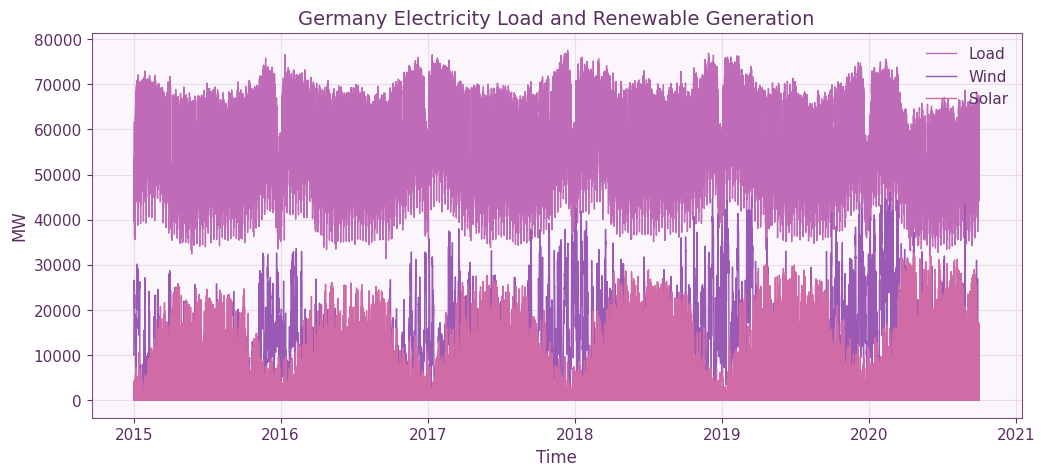

In [14]:
plt.figure(figsize=(12,5))
plt.plot(merged["utc_timestamp"], merged["load_mw"], label="Load", linewidth=1)
plt.plot(merged["utc_timestamp"], merged["wind_generation_mw"], label="Wind", linewidth=1)
plt.plot(merged["utc_timestamp"], merged["solar_generation_mw"], label="Solar", linewidth=1)

plt.legend()
plt.title("Germany Electricity Load and Renewable Generation")
plt.xlabel("Time")
plt.ylabel("MW")
plt.show()

The time-series plot shows hourly electricity demand (load) alongside wind and solar generation in Germany between 2015 and 2020. Electricity load fluctuates between approximately 30 GW and 77 GW, reflecting daily demand cycles and seasonal variations. Demand generally peaks during winter periods due to increased heating and reduced daylight hours.

Wind generation exhibits significant variability throughout the dataset. Periods of strong wind conditions produce generation peaks exceeding 40 GW, while calm periods result in substantially lower output. This variability highlights the intermittent nature of wind energy.

Solar generation displays a strong seasonal and daily cycle, with generation occurring only during daylight hours and peaking during summer months when solar irradiance is highest.

Overall, the plot demonstrates that while renewable energy contributes significantly to electricity supply, it does not consistently match total electricity demand. This mismatch between renewable generation and demand motivates the analysis of renewable energy shortfalls in the German power system.

### Distribution of Variables

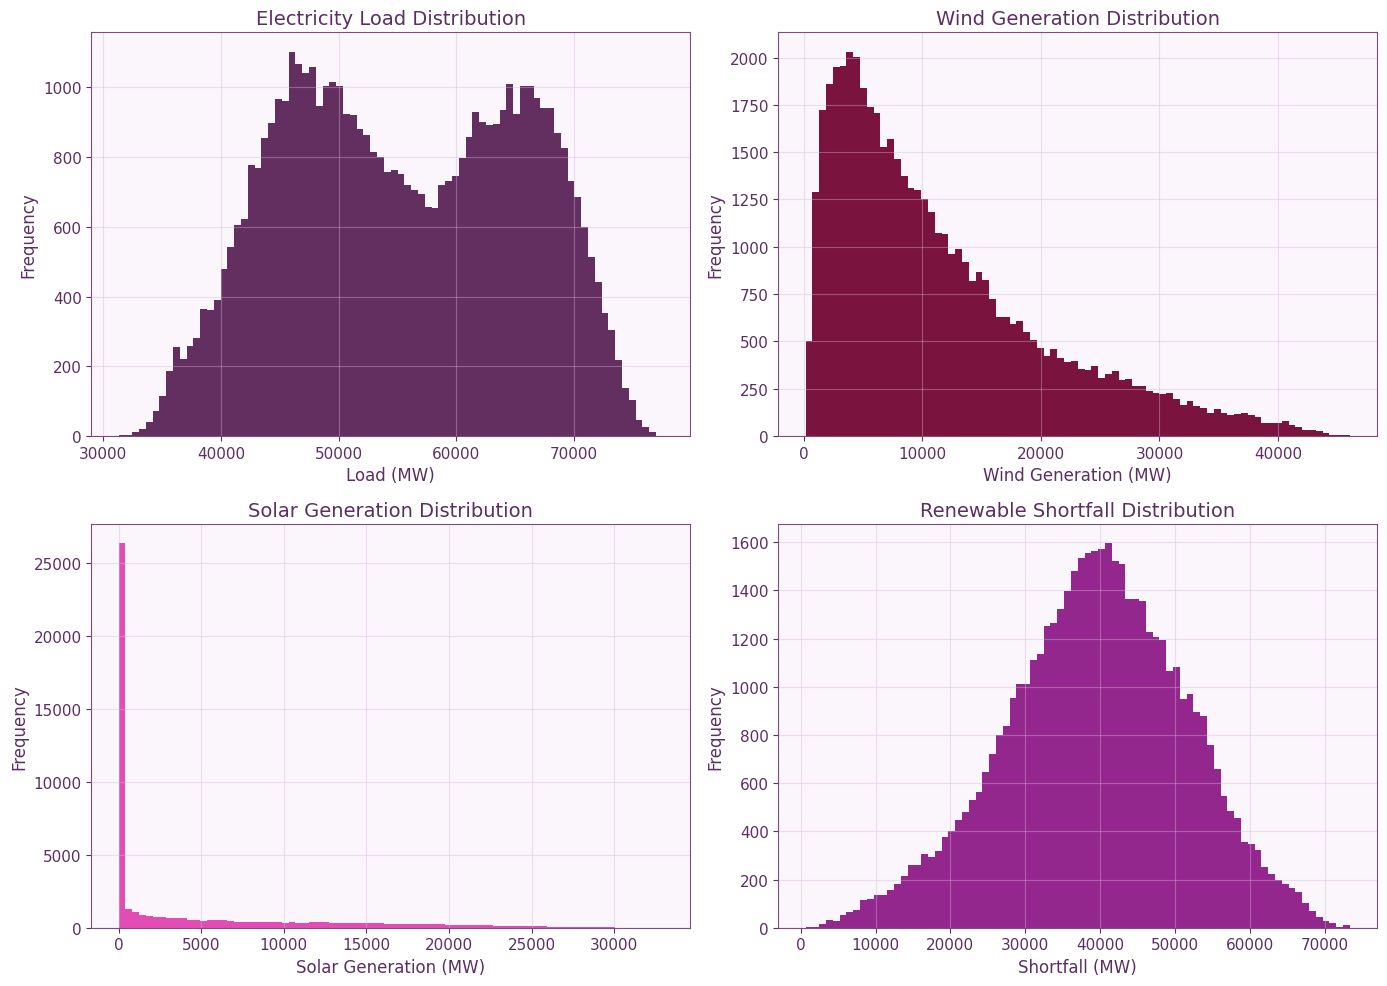

In [15]:
fig, axes = plt.subplots(2,2, figsize=(14,10))

merged["load_mw"].hist(ax=axes[0,0], bins=80, color="#632f60")
axes[0,0].set_title("Electricity Load Distribution")
axes[0,0].set_xlabel("Load (MW)")
axes[0,0].set_ylabel("Frequency")

merged["wind_generation_mw"].hist(ax=axes[0,1], bins=80, color="#7a133e")
axes[0,1].set_title("Wind Generation Distribution")
axes[0,1].set_xlabel("Wind Generation (MW)")
axes[0,1].set_ylabel("Frequency")

merged["solar_generation_mw"].hist(ax=axes[1,0], bins=80, color="#e24cb5")
axes[1,0].set_title("Solar Generation Distribution")
axes[1,0].set_xlabel("Solar Generation (MW)")
axes[1,0].set_ylabel("Frequency")

merged["shortfall_mw"].hist(ax=axes[1,1], bins=80, color="#94278e")
axes[1,1].set_title("Renewable Shortfall Distribution")
axes[1,1].set_xlabel("Shortfall (MW)")
axes[1,1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

#### Plot 1
The electricity load distribution appears bimodal, indicating two dominant demand regimes. Lower demand values likely correspond to periods of reduced consumption such as nighttime or warmer months, while higher demand levels correspond to periods of increased electricity use, particularly during winter when heating demand rises.
#### Plot 2
Wind generation exhibits a positively skewed distribution, indicating that lower levels of wind generation occur more frequently while high generation events are less common but possible during periods of strong wind conditions.
#### Plot 3
Solar generation shows a large concentration of values at zero, reflecting the absence of solar generation during nighttime hours. The long tail of higher values corresponds to daylight periods with increasing solar irradiance.
#### Plot 4
The renewable shortfall distribution is approximately normally distributed, centered around 40,000 MW. This indicates that renewable generation frequently supplies only a portion of electricity demand, requiring additional generation sources to meet total system load.

### Shortfall Behaviour

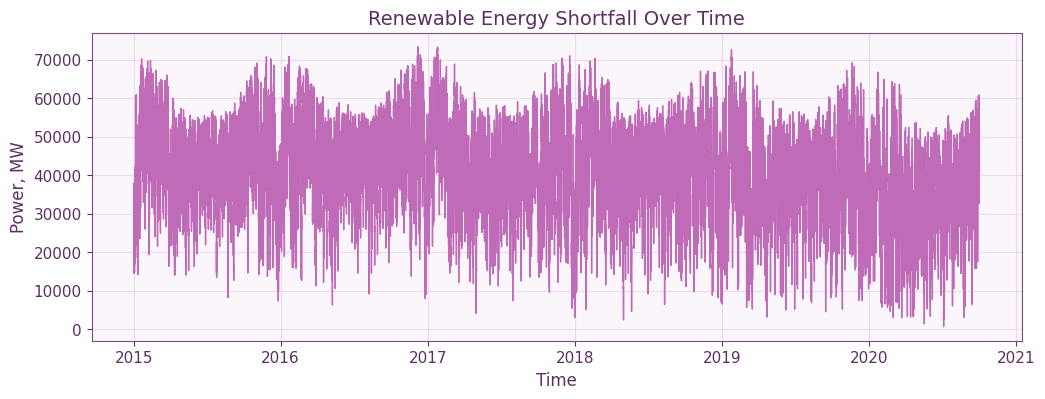

In [16]:
plt.figure(figsize=(12,4))
plt.plot(merged["utc_timestamp"], merged["shortfall_mw"], linewidth=1)
plt.title("Renewable Energy Shortfall Over Time")
plt.xlabel("Time")
plt.ylabel("Power, MW")
plt.show()

The time-series plot illustrates the renewable energy shortfall in Germany from 2015 to 2020. Renewable shortfall is defined as the difference between electricity demand and the combined generation from wind and solar power. Positive values therefore indicate the portion of electricity demand that must be supplied by other energy sources such as hydroelectric power, natural gas, coal, or imports.

The plot shows significant variability in renewable shortfalls across the study period. Most values lie between approximately 20,000 MW and 60,000 MW, with an average shortfall of roughly 39,000 MW. This indicates that wind and solar generation alone are typically insufficient to meet total electricity demand.

Seasonal patterns are also visible. Shortfalls tend to decrease during periods of high renewable generation, particularly when wind output increases or during summer months when solar generation peaks. Conversely, larger shortfalls occur when renewable generation is low relative to demand.

The high variability in the shortfall highlights the intermittent nature of renewable energy sources and underscores the importance of additional generation capacity, energy storage, or demand management strategies to ensure reliable electricity supply.

### Renewable Contribution

In [17]:
merged["renewable_share"] = (
    merged["wind_generation_mw"]
    + merged["solar_generation_mw"]
) / merged["load_mw"]

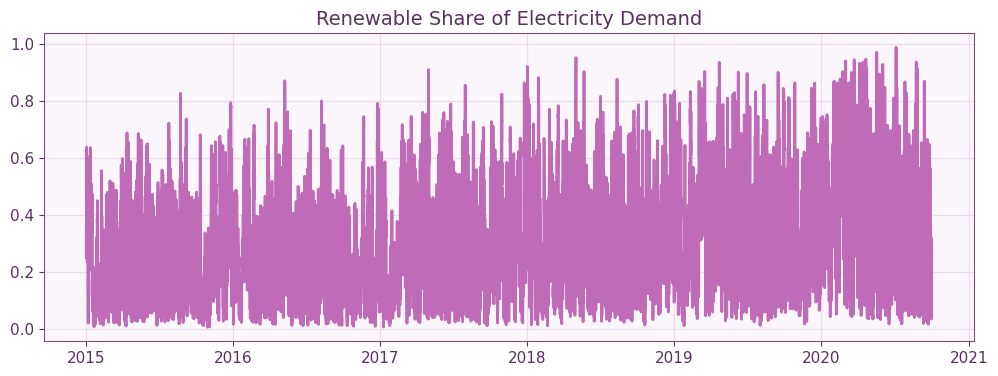

In [18]:
plt.figure(figsize=(12,4))
plt.plot(merged["utc_timestamp"], merged["renewable_share"])
plt.title("Renewable Share of Electricity Demand")
plt.show()

The plot illustrates the proportion of Germany’s electricity demand that is met by wind and solar generation between 2015 and 2020. The renewable share is calculated as the ratio of total renewable generation (wind plus solar) to total electricity load.

The figure shows substantial variability in the renewable share over time. In many hours, renewable sources contribute less than 20–30% of total electricity demand, particularly during periods of low wind conditions or nighttime when solar generation is unavailable.

However, there are also periods when renewable generation accounts for a much larger share of electricity demand. In some instances, the renewable share approaches 80–100%, indicating that wind and solar generation can occasionally meet most of the electricity demand during favorable weather conditions.

Overall, the plot demonstrates both the growing contribution of renewable energy and the variability associated with wind and solar resources. This variability contributes directly to renewable energy shortfalls and highlights the importance of complementary energy sources or storage systems to ensure reliable electricity supply.

### Weather vs Generation Relationships

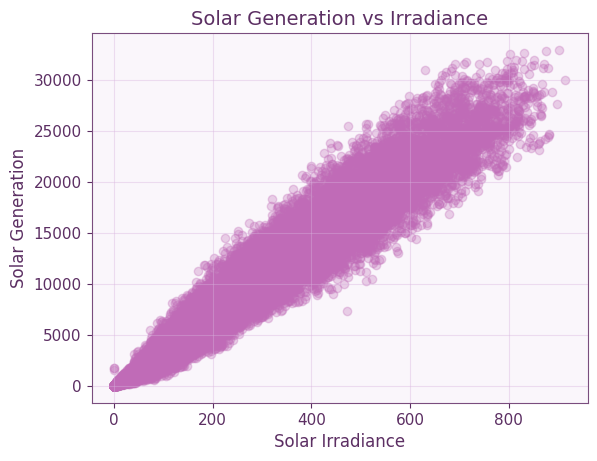

In [19]:
# Relationship between solar generation and irradiance
plt.scatter(
    merged["irradiance_wm2"],
    merged["solar_generation_mw"],
    alpha=0.3
)
plt.xlabel("Solar Irradiance")
plt.ylabel("Solar Generation")
plt.title("Solar Generation vs Irradiance")
plt.show()

The scatter plot demonstrates a strong positive relationship between solar irradiance and solar electricity generation. As irradiance increases, solar power output also increases, confirming that solar generation is strongly dependent on available sunlight. The relationship appears approximately linear across most irradiance values, indicating that solar generation increases proportionally with solar irradiance under typical operating conditions.
Although the overall relationship is strong, some variability is observed for similar irradiance levels. This spread likely results from differences in solar installation locations, panel orientation, cloud cover variability, and other environmental factors affecting solar power production. At low irradiance levels, solar generation approaches zero, reflecting nighttime conditions or periods with minimal sunlight. 


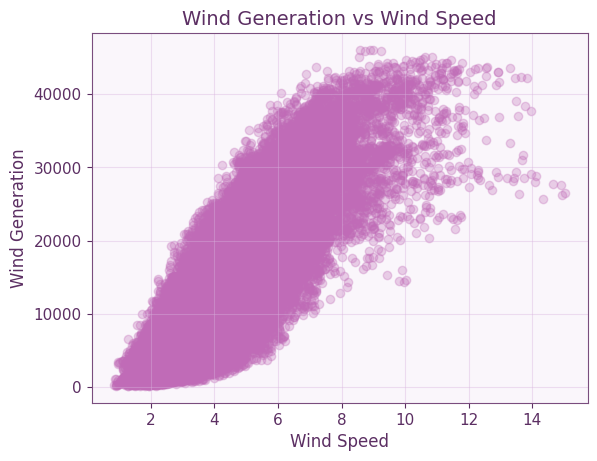

In [20]:
# Relationship between wind generation and wind speed
plt.scatter(
    merged["wind_speed_10m_ms"],
    merged["wind_generation_mw"],
    alpha=0.3
)
plt.xlabel("Wind Speed")
plt.ylabel("Wind Generation")
plt.title("Wind Generation vs Wind Speed")
plt.show()

The scatter plot illustrates the relationship between wind speed and wind electricity generation in Germany. As wind speed increases, wind generation also increases, indicating a positive relationship between the two variables. 
The relationship between wind speed and generation is non-linear, reflecting the physics of wind turbines, where power output increases roughly with the cube of wind speed. This causes generation to rise rapidly once wind speeds reach moderate levels. At higher wind speeds, wind generation begins to plateau, indicating that turbines are approaching their rated power output. This results in diminishing increases in generation despite further increases in wind speed.
A wide spread in the data is observed at similar wind speeds. This variability likely results from geographic differences in wind conditions, variations in turbine locations across Germany, and the aggregated nature of national generation data.

### Correlation Matrix

<Axes: >

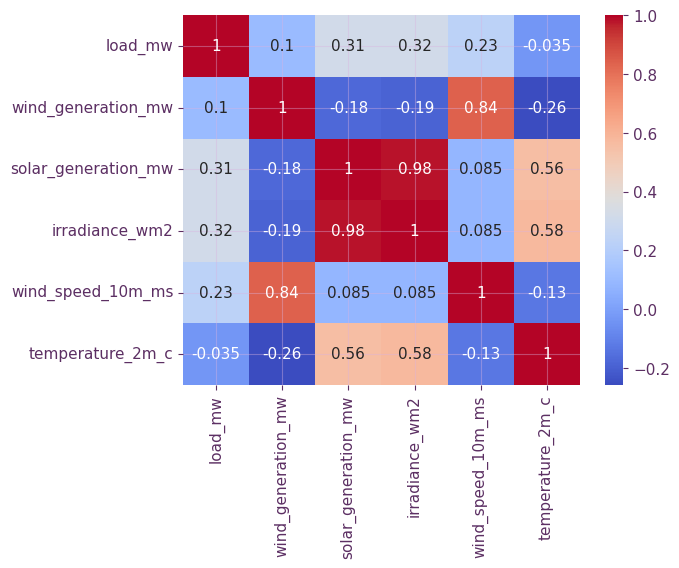

In [21]:
corr = merged[[
    "load_mw",
    "wind_generation_mw",
    "solar_generation_mw",
    "irradiance_wm2",
    "wind_speed_10m_ms",
    "temperature_2m_c"
]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")

A correlation analysis was performed to examine the relationships between electricity demand, renewable generation, and weather variables. The results highlight several strong relationships that align with the physical drivers of renewable energy production.
Solar generation shows a very strong positive correlation with solar irradiance (r ≈ 0.98). This indicates that solar power output is almost directly proportional to the amount of incoming solar radiation. The result is consistent with the physics of photovoltaic systems, where electricity production increases with available sunlight.
Wind generation is strongly correlated with wind speed (r ≈ 0.84). Higher wind speeds generally lead to greater electricity production from wind turbines. The relationship is not perfectly linear due to turbine operating limits and the nonlinear dependence of power on wind speed.
Temperature shows a moderate positive correlation with solar irradiance (r ≈ 0.58). This relationship occurs because both variables are influenced by solar radiation and seasonal patterns, with higher temperatures typically occurring during periods of stronger sunlight.
A moderate positive correlation exists between temperature and solar generation (r ≈ 0.56). Warmer conditions generally occur during periods of higher solar irradiance, which also leads to increased solar electricity production.
Electricity load shows a moderate positive correlation with solar generation and irradiance. This may reflect daily patterns in electricity demand, where higher demand often occurs during daytime hours when solar production is also active.
Wind and solar generation exhibit a weak negative correlation. This suggests that periods of strong wind are not necessarily associated with high solar generation, reflecting the differing weather conditions that influence each renewable energy source.
A weak negative correlation is observed between wind speed and temperature, suggesting that higher wind speeds may occur more frequently during cooler atmospheric conditions.
Electricity load shows little correlation with temperature in the dataset. This may occur because Germany's electricity demand is influenced by multiple factors, including industrial activity, seasonal behavior, and heating demand.

### Seasonal Patterns

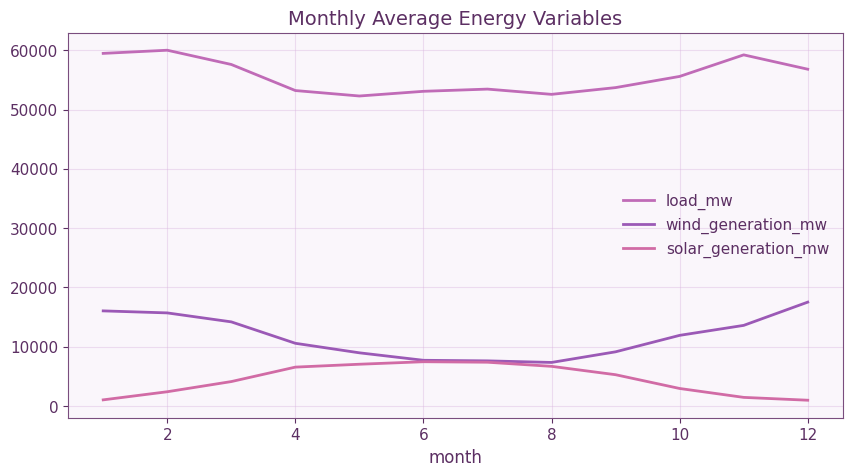

In [22]:
merged["month"] = merged["utc_timestamp"].dt.month

monthly = merged.groupby("month")[[
    "load_mw",
    "wind_generation_mw",
    "solar_generation_mw"
]].mean()

monthly.plot(figsize=(10,5))
plt.title("Monthly Average Energy Variables")
plt.show()

The figure shows the monthly average electricity load, wind generation, and solar generation in Germany. The plot highlights clear seasonal patterns in both electricity demand and renewable energy production.
Electricity demand is highest during the winter months, reaching approximately 59–60 GW in January and December. Demand decreases during spring and early summer, reaching a minimum of around 52–53 GW. This seasonal pattern likely reflects increased heating demand and lower daylight hours during winter periods.
Wind generation follows an opposite seasonal pattern to solar power. Wind output is highest during the winter months, when atmospheric conditions produce stronger and more frequent wind events. Wind generation decreases during the summer, reaching its lowest levels around May to August.
This seasonal complementarity between wind and solar generation helps stabilize renewable energy supply over the year, partially offsetting the variability of individual renewable sources. However, total renewable output still varies significantly throughout the year. During periods of low renewable generation relative to demand, electricity shortfalls must be met by other generation sources such as fossil fuels, imports, or energy storage systems.

### Extreme Events

In [23]:
merged.nlargest(10, "shortfall_mw")

,utc_timestamp,load_mw,solar_generation_mw,wind_generation_mw,shortfall_mw,irradiance_wm2,wind_speed_10m_ms,temperature_2m_c,renewable_share,month
16855,2016-12-06 16:00:00+00:00,75176.0,0.0,1806.0,73370.0,0.000,1.810,-0.464,0.024024,12
18007,2017-01-24 16:00:00+00:00,74786.0,9.0,1477.0,73300.0,0.000,1.962,-4.146,0.019870,1
18008,2017-01-24 17:00:00+00:00,74506.0,0.0,1525.0,72981.0,0.000,2.022,-4.594,0.020468,1
18001,2017-01-24 10:00:00+00:00,75845.0,2001.0,953.0,72891.0,76.982,2.020,-2.382,0.038948,1
18000,2017-01-24 09:00:00+00:00,75098.0,1435.0,798.0,72865.0,61.164,2.086,-3.342,0.029734,1
17998,2017-01-24 07:00:00+00:00,73687.0,157.0,671.0,72859.0,8.168,1.732,-5.386,0.011237,1
17984,2017-01-23 17:00:00+00:00,74620.0,0.0,1902.0,72718.0,0.000,1.836,-4.840,0.025489,1
35527,2019-01-24 16:00:00+00:00,74057.0,2.0,1400.0,72655.0,0.000,1.634,-4.442,0.018931,1
35528,2019-01-24 17:00:00+00:00,74138.0,0.0,1503.0,72635.0,0.000,1.702,-4.800,0.020273,1
17999,2017-01-24 08:00:00+00:00,73960.0,724.0,719.0,72517.0,33.072,1.960,-4.388,0.019511,1


The most severe renewable shortfall events are concentrated in the winter months, particularly January and December. This suggests that the German electricity system is most vulnerable during colder periods when electricity demand is high and solar generation is naturally limited.
Solar generation is negligible during the largest shortfall events, with many observations showing near-zero solar output. This is consistent with winter and late-afternoon conditions, when solar irradiance is minimal or absent. Similarily, solar irradiance is also near zero.
Wind generation during the most severe shortfall events remains very low relative to total system demand. Although wind contributes some electricity, its output is insufficient to offset the lack of solar generation and the high winter demand. This can be contributed to the wind speeds during the most extreme events being relatively low, generally around 1.6–2.1 m/s.
Electricity demand during the extreme shortfall events is exceptionally high, reaching approximately 74–76 GW. This indicates that severe shortfalls occur not only because renewable generation is weak, but also because system demand is simultaneously elevated. A reason for the increased electricity demand may be due to more heating needed as many of the largest shortfall events occur during sub-zero or near-freezing temperatures. 

## Part 3: Feature Engineering

## Feature Engineering for Forecasting

The following features were engineered to help the forecasting models capture weather effects, calendar seasonality, and recent system behavior. Each feature was selected because it could realistically provide predictive information about renewable energy shortfall.

### Weather Features

- **irradiance_wm2**: Average solar irradiance across the selected German cities. This was included because sunlight availability is directly related to solar power generation.
- **wind_speed_10m_ms**: Average wind speed across the selected cities. This was created because wind speed is strongly associated with wind generation output.
- **temperature_2m_c**: Average temperature near the surface. This feature was included because temperature can influence electricity demand and broader weather conditions.

### Time-Based Features

- **hour**: Hour of the day. This helps capture daily cycles in electricity demand and renewable generation.
- **day_of_week**: Day of the week. This was included to reflect differences between weekdays and weekends.
- **month**: Month of the year. This captures broad seasonal changes in weather and electricity usage.
- **day_of_year**: Numerical day within the year. This provides a finer seasonal signal than month alone.

### Lag Features Based on Shortfall

- **lag_1h_shortfall**: Shortfall observed one hour earlier. This captures short-term persistence in system behavior.
- **lag_24h_shortfall**: Shortfall observed 24 hours earlier. This helps model repeating daily patterns.
- **lag_168h_shortfall**: Shortfall observed one week earlier. This captures weekly repetition in demand and renewable output.

### Lag Features Based on Historical Energy Variables

- **lag_24h_load**: Electricity load from 24 hours earlier. This provides historical context for demand patterns.
- **lag_24h_wind**: Wind generation from 24 hours earlier. This helps represent recurring day-to-day wind generation behavior.
- **lag_24h_solar**: Solar generation from 24 hours earlier. This captures daily repetition in solar output.


In [24]:
model_df = merged.copy()

# Time-based features
model_df["hour"] = model_df["utc_timestamp"].dt.hour
model_df["day_of_week"] = model_df["utc_timestamp"].dt.dayofweek
model_df["month"] = model_df["utc_timestamp"].dt.month
model_df["day_of_year"] = model_df["utc_timestamp"].dt.dayofyear

# Lag features for shortfall
model_df["lag_1h_shortfall"] = model_df["shortfall_mw"].shift(1)
model_df["lag_24h_shortfall"] = model_df["shortfall_mw"].shift(24)
model_df["lag_168h_shortfall"] = model_df["shortfall_mw"].shift(168)

# Optional lag features for demand and renewables
model_df["lag_24h_load"] = model_df["load_mw"].shift(24)
model_df["lag_24h_wind"] = model_df["wind_generation_mw"].shift(24)
model_df["lag_24h_solar"] = model_df["solar_generation_mw"].shift(24)

# Drop rows created by lagging
model_df = model_df.dropna().copy()

print("Model dataframe shape:", model_df.shape)
model_df.head()

Model dataframe shape: (50127, 19)


,utc_timestamp,load_mw,solar_generation_mw,wind_generation_mw,shortfall_mw,irradiance_wm2,wind_speed_10m_ms,temperature_2m_c,renewable_share,month,hour,day_of_week,day_of_year,lag_1h_shortfall,lag_24h_shortfall,lag_168h_shortfall,lag_24h_load,lag_24h_wind,lag_24h_solar
168,2015-01-08 07:00:00+00:00,68569.0,57.0,18039.0,50473.0,3.554,6.176,1.860,0.263909,1,7,3,8,47371.0,58189.0,30854.0,65964.0,7725.0,50.0
169,2015-01-08 08:00:00+00:00,68599.0,446.0,18177.0,49976.0,28.414,6.304,2.450,0.271476,1,8,3,8,50473.0,58492.0,32161.0,66400.0,7299.0,609.0
170,2015-01-08 09:00:00+00:00,69484.0,1083.0,18094.0,50307.0,53.276,6.394,3.004,0.275992,1,9,3,8,49976.0,58820.0,32421.0,67746.0,7114.0,1812.0
171,2015-01-08 10:00:00+00:00,70635.0,1738.0,17924.0,50973.0,82.872,6.440,3.530,0.278361,1,10,3,8,50307.0,58218.0,32259.0,68507.0,7229.0,3060.0
172,2015-01-08 11:00:00+00:00,69962.0,2062.0,17249.0,50651.0,82.250,6.474,4.012,0.276021,1,11,3,8,50973.0,56863.0,31858.0,68100.0,7460.0,3777.0


Overall, these engineered features were created to help the models learn:
- weather-related effects on renewable generation,
- repeating hourly, daily, and weekly patterns,
- and the persistence of shortfall over time.

This combination of weather, calendar, and lagged features was intended to improve predictive performance while using information that would realistically be available from past observations.

## Part 4: Machine learning

## Machine Learning Model Development

Several machine learning models were tested to evaluate how well renewable energy shortfall could be predicted from weather, time-based, and historical lag features. The purpose of testing multiple models was to compare their performance and determine which approach best satisfied the requirements of the project.

The models were evaluated using standard regression metrics such as MAE, RMSE, and R². By comparing these results, the best-performing model was selected based on its ability to produce accurate predictions while still being interpretable for renewable energy shortfall forecasting.


### Train-Test Split for Time-Series Forecasting

In [25]:
train = model_df[model_df["utc_timestamp"] < "2020-01-01"].copy()
test = model_df[model_df["utc_timestamp"] >= "2020-01-01"].copy()

print("Training shape:", train.shape)
print("Testing shape:", test.shape)

print("Training range:", train["utc_timestamp"].min(), "to", train["utc_timestamp"].max())
print("Testing range:", test["utc_timestamp"].min(), "to", test["utc_timestamp"].max())

Training shape: (43551, 19)
Testing shape: (6576, 19)
Training range: 2015-01-08 07:00:00+00:00 to 2019-12-31 23:00:00+00:00
Testing range: 2020-01-01 00:00:00+00:00 to 2020-09-30 23:00:00+00:00


The dataset was divided chronologically into training and testing subsets in order to preserve the time-series structure of the data. The training set contains 43,551 observations and spans from 8 January 2015 to 31 December 2019, while the testing set contains 6,576 observations and covers the period from 1 January 2020 to 30 September 2020.
This chronological split is appropriate for forecasting problems because it ensures that the model is trained only on past data and evaluated on future data. In this way, the testing set provides a realistic assessment of how well the model would perform in practice when predicting unseen shortfall values.
The training period begins on 8 January 2015 rather than 1 January 2015 because lagged predictor variables were created. These lag features introduce missing values at the start of the dataset, and the affected rows were removed before modeling.

## Random Forest Model 1: Weather Features Only

This first Random Forest model uses only the observed weather variables and calendar features. It acts as a simpler baseline to show how much predictive power comes from environmental conditions and seasonality alone, before adding historical lag information.


In [26]:
feature_cols_weather = [
    "irradiance_wm2",
    "wind_speed_10m_ms",
    "temperature_2m_c",
    "hour",
    "day_of_week",
    "month",
    "day_of_year"
]

target_col = "shortfall_mw"

X_train_weather = train[feature_cols_weather]
y_train = train[target_col]

X_test_weather = test[feature_cols_weather]
y_test = test[target_col]

print("X_train shape:", X_train_weather.shape)
print("X_test shape:", X_test_weather.shape)


X_train shape: (43551, 7)
X_test shape: (6576, 7)


The weather-only Random Forest model was trained using 43,551 hourly observations and evaluated on 6,576 hourly observations. This model used seven predictors: three weather variables and four calendar-based variables. The purpose of this model was to provide a baseline showing how well renewable energy shortfall could be predicted using only weather conditions and seasonal time patterns, without using previous shortfall or energy-generation values.

In [27]:
rf_weather = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=4,
    random_state=42,
    n_jobs=-1
)

rf_weather.fit(X_train_weather, y_train)

y_pred_rf_weather = rf_weather.predict(X_test_weather)

print("Random Forest weather-only model trained successfully.")


Random Forest weather-only model trained successfully.


In [28]:
mae_rf_weather = mean_absolute_error(y_test, y_pred_rf_weather)
rmse_rf_weather = np.sqrt(mean_squared_error(y_test, y_pred_rf_weather))
r2_rf_weather = r2_score(y_test, y_pred_rf_weather)

print("Random Forest Weather-Only Performance")
print(f"MAE:  {mae_rf_weather:,.2f} MW")
print(f"RMSE: {rmse_rf_weather:,.2f} MW")
print(f"R²:   {r2_rf_weather:.4f}")


Random Forest Weather-Only Performance
MAE:  6,794.38 MW
RMSE: 8,234.11 MW
R²:   0.5284


The weather-only Random Forest model produced an MAE of 6,794.38 MW, an RMSE of 8,234.11 MW, and an R² value of 0.5284. This means the model explains about 52.84% of the variation in renewable energy shortfall using only weather variables and calendar-based time features.

The MAE shows that, on average, the model’s predictions were off by about 6,794 MW. The RMSE is higher than the MAE, which suggests that the model made some larger prediction errors on certain hours. This is expected because renewable shortfall can change sharply when demand, wind generation, or solar generation shifts.

Overall, this model performs reasonably well as a baseline. Since it does not use previous shortfall, load, wind generation, or solar generation values, its performance shows that weather conditions and seasonal time patterns contain meaningful information for predicting renewable energy shortfall. However, the remaining error suggests that weather-only features are not enough to fully capture the behavior of the energy system.

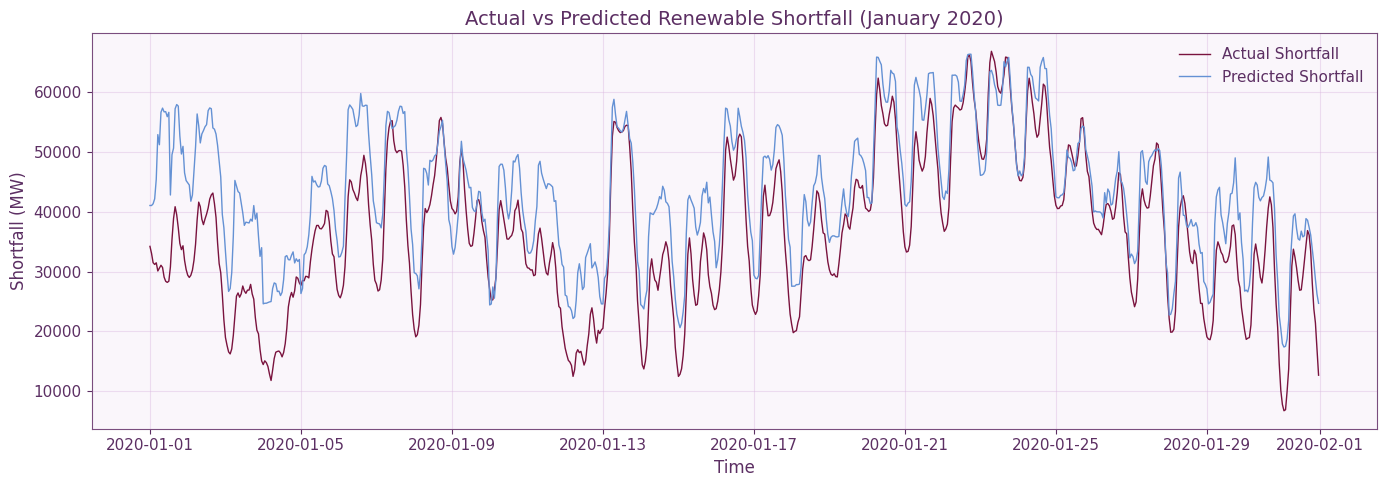

In [47]:
results_rf_weather = test[["utc_timestamp", "shortfall_mw"]].copy()
results_rf_weather["predicted_shortfall_mw"] = y_pred_rf_weather

plot_rf_weather = results_rf_weather[
    (results_rf_weather["utc_timestamp"] >= "2020-01-01") &
    (results_rf_weather["utc_timestamp"] < "2020-02-01")
]

plt.figure(figsize=(14,5))
plt.plot(plot_rf_weather["utc_timestamp"], plot_rf_weather["shortfall_mw"], label="Actual Shortfall", color="#7a133e", linewidth=1)
plt.plot(plot_rf_weather["utc_timestamp"], plot_rf_weather["predicted_shortfall_mw"], label="Predicted Shortfall", color="#6491D4", linewidth=1)
plt.title("Actual vs Predicted Renewable Shortfall (January 2020)")
plt.xlabel("Time")
plt.ylabel("Shortfall (MW)")
plt.legend()
plt.tight_layout()
plt.show()


The weather-only Random Forest plot shows that the model captures the general movement of renewable shortfall, but it does not track the actual values as closely a full-feature model might. The predicted line follows some of the same rises and falls, especially during broad periods of high or low shortfall, but there are several areas where the predictions are noticeably above or below the actual values.

This weaker fit is expected because the weather-only model only uses weather and calendar features. It does not have access to previous shortfall values or historical load, wind, and solar generation, so it has less information about the recent state of the energy system.

The model appears to overpredict shortfall during some lower-shortfall periods and miss some sharper drops and peaks. This suggests that weather and time variables are useful, but they are not enough to fully explain short-term changes in renewable shortfall.

Overall, the weather-only model works as a useful baseline. It shows that weather conditions and seasonal patterns contain predictive information, but the stronger performance of the lag-based models suggests that historical shortfall and energy behavior are much more important for accurate short-term forecasting.


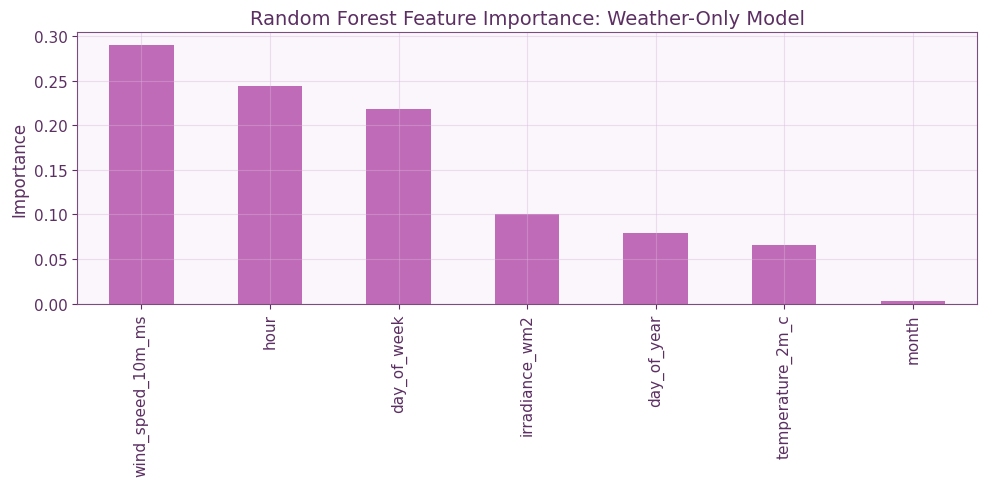

wind_speed_10m_ms    0.289468
hour                 0.243914
day_of_week          0.218374
irradiance_wm2       0.100494
day_of_year          0.079282
temperature_2m_c     0.065659
month                0.002809
dtype: float64

In [29]:
feature_importance_rf_weather = pd.Series(rf_weather.feature_importances_, index=feature_cols_weather)
feature_importance_rf_weather = feature_importance_rf_weather.sort_values(ascending=False)

plt.figure(figsize=(10,5))
feature_importance_rf_weather.plot(kind="bar")
plt.title("Random Forest Feature Importance: Weather-Only Model")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

feature_importance_rf_weather


The feature importance results show that **wind_speed_10m_ms** was the most important predictor in the weather-only Random Forest model, with an importance score of 0.2895. This suggests that wind conditions play a major role in explaining renewable shortfall, which is reasonable because wind generation is a major component of renewable electricity supply.

The next most important features were **hour** and **day_of_week**, with importance scores of 0.2439 and 0.2184. This indicates that the model relied heavily on daily and weekly time patterns. Electricity demand and renewable output often vary depending on the time of day and whether it is a weekday or weekend.

**irradiance_wm2** also contributed to the model, with an importance of 0.1005. This reflects the role of solar conditions in renewable generation, although it was less important than wind speed in this model. This may suggest that wind generation has a larger influence on renewable shortfall than solar generation in the dataset.

**day_of_year** and **temperature_2m_c** had smaller but still meaningful contributions. These features likely helped capture broader seasonal patterns and weather-related demand changes. **month** had very low importance, which may be because seasonal information was already captured more precisely by **day_of_year**.

Overall, the weather-only model appears to depend mostly on wind speed and calendar patterns, showing that both weather conditions and time-based seasonality are important for predicting renewable energy shortfall.


## Random Forest Model 2: Full Feature Set

The final Random Forest model uses the complete engineered feature set. This version is expected to perform best for short-term forecasting because it combines weather information, calendar structure, and very recent historical behavior.


### Why Shortfall Lag Features Were Included

Lagged shortfall variables were added because renewable energy shortfall is a time-dependent variable that often shows strong persistence and repeating patterns over time. In hourly electricity data, the shortfall at a given time is usually influenced by what happened in the previous hour, the previous day at the same hour, and the same hour in the previous week.

- **lag_1h_shortfall** was included to capture very short-term persistence. If the system experienced a high or low shortfall one hour earlier, that information is often still relevant in the next hour because changes in load and renewable output are usually gradual rather than random.
- **lag_24h_shortfall** was added to capture daily repetition. Electricity demand and renewable generation often follow similar patterns at the same hour on consecutive days, so the shortfall from 24 hours earlier can provide useful predictive information.
- **lag_168h_shortfall** was included to capture weekly seasonality. Since demand and renewable generation patterns often differ between weekdays and weekends, the shortfall from the same hour one week earlier can help the model learn these recurring weekly effects.

These lag features work well for this dataset because the data is **hourly**, spans **multiple years**, and contains clear **daily and weekly seasonal structure**. In this kind of time series, past shortfall values provide meaningful context for predicting future shortfall. Including lagged shortfall therefore helps the model capture persistence, seasonality, and recurring system behavior more effectively.


In [34]:
feature_cols = [
    "irradiance_wm2",
    "wind_speed_10m_ms",
    "temperature_2m_c",
    "hour",
    "day_of_week",
    "month",
    "day_of_year",
    "lag_1h_shortfall",
    "lag_24h_shortfall",
    "lag_168h_shortfall",
    "lag_24h_load",
    "lag_24h_wind",
    "lag_24h_solar"
]

X_train = train[feature_cols]
y_train = train[target_col]

X_test = test[feature_cols]
y_test = test[target_col]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)


X_train shape: (43551, 13)
X_test shape: (6576, 13)


In [35]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=4,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest full-feature model trained successfully.")


Random Forest full-feature model trained successfully.


In [36]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Full-Feature Performance")
print(f"MAE:  {mae_rf:,.2f} MW")
print(f"RMSE: {rmse_rf:,.2f} MW")
print(f"R²:   {r2_rf:.4f}")


Random Forest Full-Feature Performance
MAE:  1,129.29 MW
RMSE: 1,494.50 MW
R²:   0.9845


The full-feature Random Forest model achieved an MAE of 1,129.29 MW, an RMSE of 1,494.50 MW, and an R² value of 0.9845. This means the model explained approximately 98.45% of the variation in renewable energy shortfall on the test set.

Compared with the weather-only model, this is a major improvement. The weather-only model had an MAE of 6,794.38 MW and an RMSE of 8,234.11 MW, while the full-feature model reduced the average prediction error to about 1,129 MW. This shows that adding historical lag features provided much more predictive information than weather and calendar variables alone.

The strong performance is expected because renewable shortfall is highly time-dependent. The full model includes previous shortfall values from 1 hour, 24 hours, and 168 hours earlier, which help capture short-term persistence, daily cycles, and weekly patterns. In particular, `lag_1h_shortfall` gives the model very recent information about the target variable, which can make short-term predictions much more accurate.

However, this result should be interpreted carefully. The full-feature model is best understood as a short-term forecasting model, especially suitable for next-hour prediction. Its high R² does not necessarily mean the model would perform as well for longer forecasting horizons where the most recent shortfall value may not be available.

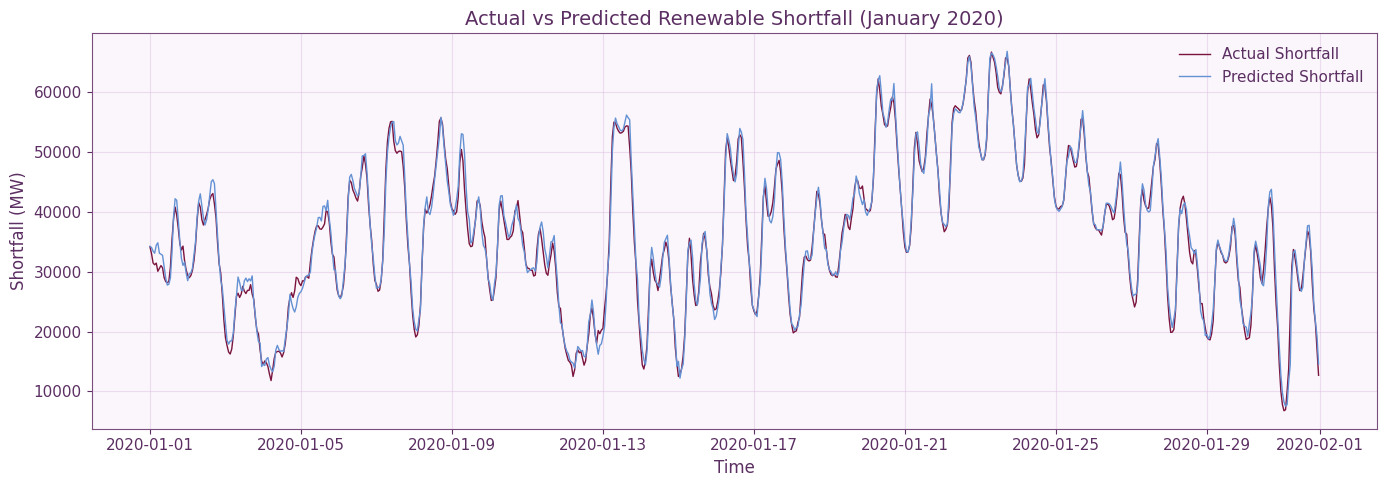

In [37]:
results_rf = test[["utc_timestamp", "shortfall_mw"]].copy()
results_rf["predicted_shortfall_mw"] = y_pred_rf

plot_rf = results_rf[
    (results_rf["utc_timestamp"] >= "2020-01-01") &
    (results_rf["utc_timestamp"] < "2020-02-01")
]

plt.figure(figsize=(14,5))
plt.plot(plot_rf["utc_timestamp"], plot_rf["shortfall_mw"], label="Actual Shortfall", color="#7a133e", linewidth=1)
plt.plot(plot_rf["utc_timestamp"], plot_rf["predicted_shortfall_mw"], label="Predicted Shortfall", color="#6491D4", linewidth=1)
plt.title("Actual vs Predicted Renewable Shortfall (January 2020)")
plt.xlabel("Time")
plt.ylabel("Shortfall (MW)")
plt.legend()
plt.tight_layout()
plt.show()


The January 2020 actual vs predicted plot shows that the full-feature Random Forest model closely follows the actual renewable shortfall values throughout the month. The predicted shortfall line almost overlaps with the actual shortfall line for most time periods, indicating that the model captures both the general trend and the short-term fluctuations in the data.

The model performs especially well during repeated rises and drops in shortfall, suggesting that the lag features are helping it learn short-term persistence and recurring hourly patterns. This matches the high R² value of 0.9845 and the relatively low MAE and RMSE values.

There are still small differences between the actual and predicted values, especially around sharp peaks and sudden drops. This is expected because sudden changes in renewable generation or electricity demand can be difficult to predict perfectly. However, the overall fit is very strong, showing that the full-feature model is effective for short-term renewable shortfall prediction.

Because the predicted values are extremely close to the actual values, the result should be interpreted as short-term forecasting performance rather than long-term forecasting performance. The strong fit is likely influenced by the inclusion of lagged shortfall features, especially `lag_1h_shortfall`, which gives the model recent information about the target variable.


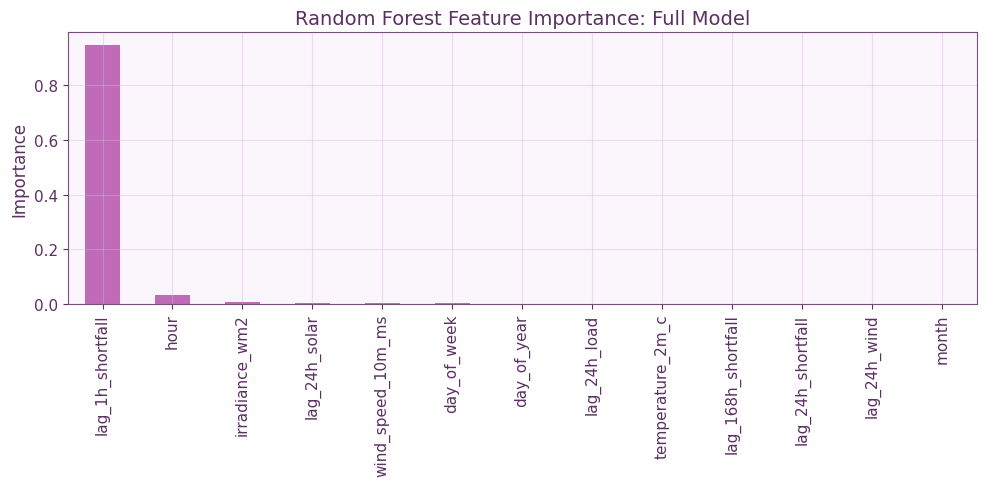

lag_1h_shortfall      0.947139
hour                  0.032266
irradiance_wm2        0.006785
lag_24h_solar         0.004281
wind_speed_10m_ms     0.002589
day_of_week           0.002272
day_of_year           0.001014
lag_24h_load          0.000978
temperature_2m_c      0.000953
lag_168h_shortfall    0.000633
lag_24h_shortfall     0.000492
lag_24h_wind          0.000441
month                 0.000159
dtype: float64

In [38]:
feature_importance_rf = pd.Series(rf.feature_importances_, index=feature_cols)
feature_importance_rf = feature_importance_rf.sort_values(ascending=False)

plt.figure(figsize=(10,5))
feature_importance_rf.plot(kind="bar")
plt.title("Random Forest Feature Importance: Full Model")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

feature_importance_rf


The feature importance plot shows that **lag_1h_shortfall** is by far the most important predictor in the full Random Forest model. Its importance is much higher than all other features, meaning the model relies heavily on the shortfall value from the previous hour when making predictions.

This result makes sense because renewable energy shortfall is highly persistent over short time periods. The shortfall at one hour is usually very similar to the shortfall in the next hour unless there is a sudden change in electricity demand, wind generation, or solar generation. As a result, the previous hour’s shortfall provides very strong information for predicting the current hour.

The remaining features, such as **hour**, **irradiance_wm2**, **lag_24h_solar**, and **wind_speed_10m_ms**, have much smaller importance values. This suggests that once the model knows the previous hour’s shortfall, most other variables provide only smaller adjustments.

Overall, this confirms that the full-feature model’s high performance is mainly driven by short-term persistence in the dataset. The model is effective for short-term forecasting, but its results should be interpreted carefully because it depends strongly on recent target history.

When the one-hour lagged shortfall is removed, the model relies more heavily on daily patterns, weather conditions, and demand-related variables. This reveals that renewable shortfall is influenced not only by short-term persistence but also by predictable cyclical behavior and meteorological factors.

### Comparision of Random Forest Models 

In [45]:
rf_comparison = pd.DataFrame({
    "Model": [
        "Random Forest (Weather Only)",
        "Random Forest (Full Feature Set)"
    ],
    "MAE": [
        mae_rf_weather,
        mae_rf
    ],
    "RMSE": [
        rmse_rf_weather,
        rmse_rf
    ],
    "R2": [
        r2_rf_weather,
        r2_rf
    ]
})

rf_comparison = rf_comparison.sort_values(by="RMSE").reset_index(drop=True)
rf_comparison


,Model,MAE,RMSE,R2
0,Random Forest (Full Feature Set),1129.287435,1494.502748,0.984464
1,Random Forest (Weather Only),6794.377874,8234.111929,0.528396


The model comparison shows that the **Random Forest Full Feature Set** performed much better than the **Random Forest Weather Only** model across all evaluation metrics. The full-feature model achieved a much lower MAE of 1,129.29 MW compared with 6,794.38 MW for the weather-only model. This means the full-feature model had a much smaller average prediction error.

The RMSE also decreased from 8,234.11 MW in the weather-only model to 1,494.50 MW in the full-feature model. Since RMSE penalizes larger errors more strongly, this indicates that the full-feature model was much better at avoiding large prediction mistakes.

The R² value increased from 0.5284 to 0.9845, meaning the weather-only model explained about 52.84% of the variation in renewable shortfall, while the full-feature model explained about 98.45%. This large improvement shows that adding historical lag features greatly improved the model’s ability to predict renewable energy shortfall.

Overall, the results suggest that weather and calendar features provide a useful baseline, but the strongest predictive performance comes from including historical shortfall and energy-system behavior. This is expected for hourly energy data because shortfall often follows strong short-term, daily, and weekly patterns.

## Part 6: Prophet-Based Shortfall Forecasting and Model Comparison

This section applies Prophet to forecast renewable energy shortfall and compares its performance with the Random Forest model developed earlier. The goal is to evaluate whether a time series forecasting method with weather-based regressors can provide competitive short-term predictions. Model performance is assessed using MAE, RMSE, and R².

### Prepare Prophet data

In [40]:
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

prophet_df = model_df[[
    "utc_timestamp",
    "shortfall_mw",
    "irradiance_wm2",
    "wind_speed_10m_ms",
    "temperature_2m_c"
]].copy()

prophet_df = prophet_df.rename(columns={
    "utc_timestamp": "ds",
    "shortfall_mw": "y"
})

prophet_df["ds"] = pd.to_datetime(prophet_df["ds"]).dt.tz_localize(None)

train_prophet = prophet_df[prophet_df["ds"] < "2020-01-01"].copy()
test_prophet = prophet_df[prophet_df["ds"] >= "2020-01-01"].copy()

print(train_prophet.shape, test_prophet.shape)

C:\Users\earth\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(43551, 5) (6576, 5)


### Fit Prophet

In [41]:
m = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=True
)

m.add_regressor("irradiance_wm2")
m.add_regressor("wind_speed_10m_ms")
m.add_regressor("temperature_2m_c")

m.fit(train_prophet)

16:10:24 - cmdstanpy - INFO - Chain [1] start processing
16:11:50 - cmdstanpy - INFO - Chain [1] done processing


### Predict

In [42]:
forecast_prophet = m.predict(test_prophet[[
    "ds",
    "irradiance_wm2",
    "wind_speed_10m_ms",
    "temperature_2m_c"
]])

results_prophet = test_prophet[["ds", "y"]].copy()
results_prophet["yhat"] = forecast_prophet["yhat"].values
results_prophet["yhat_lower"] = forecast_prophet["yhat_lower"].values
results_prophet["yhat_upper"] = forecast_prophet["yhat_upper"].values

results_prophet.head()

,ds,y,yhat,yhat_lower,yhat_upper
43719,2020-01-01 00:00:00,34197.0,29473.050945,22714.850650,35967.428633
43720,2020-01-01 01:00:00,33027.0,28576.015623,21680.833883,34998.589333
43721,2020-01-01 02:00:00,31471.0,29404.962450,22847.532381,36322.406182
43722,2020-01-01 03:00:00,31180.0,31944.318389,25477.011210,38626.731241
43723,2020-01-01 04:00:00,31459.0,36259.287033,29620.338884,42735.929957


### Evaluation

In [43]:
mae_prophet = mean_absolute_error(results_prophet["y"], results_prophet["yhat"])
rmse_prophet = np.sqrt(mean_squared_error(results_prophet["y"], results_prophet["yhat"]))
r2_prophet = r2_score(results_prophet["y"], results_prophet["yhat"])

print("Prophet Performance")
print(f"MAE:  {mae_prophet:,.2f} MW")
print(f"RMSE: {rmse_prophet:,.2f} MW")
print(f"R²:   {r2_prophet:.4f}")

Prophet Performance
MAE:  4,514.73 MW
RMSE: 5,726.45 MW
R²:   0.7719


### Comparison Table

In [49]:
comparison = pd.DataFrame({
    "Model": ["Random Forest Weather", "Random Forest Full Feature", "Prophet"],
    "MAE": [mae_rf_weather,mae_rf, mae_prophet],
    "RMSE": [rmse_rf_weather, rmse_rf, rmse_prophet],
    "R2": [r2_rf_weather, r2_rf, r2_prophet]
})

comparison

,Model,MAE,RMSE,R2
0,Random Forest Weather,6794.377874,8234.111929,0.528396
1,Random Forest Full Feature,1129.287435,1494.502748,0.984464
2,Prophet,4514.728903,5726.445093,0.771906


The model comparison shows clear differences in predictive performance across the three approaches. The **Random Forest Weather** model had the weakest performance, with an MAE of 6,794.38 MW, an RMSE of 8,234.11 MW, and an R² of 0.5284. This means that weather and calendar features alone explained about 52.84% of the variation in renewable shortfall. While this is a useful baseline, the relatively high error values show that weather-only features do not fully capture short-term changes in the energy system.

The **Prophet** model performed better than the weather-only Random Forest, with an MAE of 4,514.73 MW, an RMSE of 5,726.45 MW, and an R² of 0.7719. This suggests that Prophet was better able to capture the time-series structure of the data, including daily, weekly, and yearly seasonal patterns. Its improvement over the weather-only Random Forest shows that renewable shortfall is strongly influenced by recurring temporal patterns, not just weather conditions.

The **Random Forest Full Feature** model performed the best overall, with the lowest MAE of 1,129.29 MW, the lowest RMSE of 1,494.50 MW, and the highest R² of 0.9845. This means it explained about 98.45% of the variation in renewable shortfall. The major improvement is mainly due to the inclusion of lag features, especially recent shortfall values, which allow the model to capture short-term persistence, daily patterns, and weekly repetition.

Overall, the results show that adding historical lag features greatly improves forecasting accuracy. Prophet performed well because it is designed for time-series seasonality, but the full-feature Random Forest produced the strongest results because it combined weather, calendar variables, and historical energy-system behavior.

Although the **Random Forest Full Feature** model had the best numerical performance, **Prophet is the most sensible model to select for this project** because it is specifically designed for time-series forecasting. Renewable energy shortfall is an hourly time-series problem with clear daily, weekly, and yearly patterns. Prophet is built to model these recurring seasonal patterns directly, making it a more appropriate choice when the goal is to forecast future values over time.

Prophet also provides a more realistic forecasting approach than the full-feature Random Forest model because it does not depend on very recent target lag features such as `lag_1h_shortfall`. The full-feature Random Forest performed extremely well, but much of that performance came from using the previous hour’s shortfall, which makes it best suited for very short-term forecasting. Prophet, on the other hand, focuses on learning the underlying time-based structure of the data, which makes it easier to justify for general forecasting.

Prophet outperformed the **Random Forest Weather** model because the weather-only Random Forest was limited to weather and calendar variables. While those features are useful, they do not fully capture the repeating time-series patterns in renewable shortfall. Prophet explicitly models daily, weekly, and yearly seasonality, allowing it to better represent the natural cycles in electricity demand and renewable generation.

This is reflected in the results. Prophet achieved a lower MAE and RMSE than the weather-only Random Forest and a higher R² value. This means Prophet made smaller prediction errors and explained more variation in renewable shortfall. Overall, Prophet was chosen as the most sensible model because it balances strong predictive performance with a forecasting method that is more appropriate and interpretable for time-series data.
